In [90]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [91]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from utils.integral import grid
from Models.clustering import IFCF, FCF
import torch

In [92]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import numpy as np

# ===== Load MNIST =====
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="../dataset/data", train=True, download=True, transform=transform)

# ===== Cấu hình riêng cho từng label =====
labels_to_take = {0: 10, 5: 50}   # label: số ảnh cần lấy

pdf_list = []
selected_labels = []
counts = {lbl: 0 for lbl in labels_to_take}

for img, label in train_dataset:
    if label in labels_to_take and counts[label] < labels_to_take[label]:
        arr = (img.squeeze(0).numpy())   # (28,28), giá trị gốc [0..255]

        # chỉ lấy pixel > 0
        mask = arr > 0
        weights = arr * mask
        pdf = weights / weights.sum()  # chuẩn hoá thành phân phối xác suất

        pdf_list.append(pdf)
        selected_labels.append(label)
        counts[label] += 1

    # nếu đủ số lượng cho tất cả label thì dừng
    if all(counts[lbl] >= labels_to_take[lbl] for lbl in labels_to_take):
        break

F_data = np.array(pdf_list)       # (20, 28, 28)
selected_labels = np.array(selected_labels)



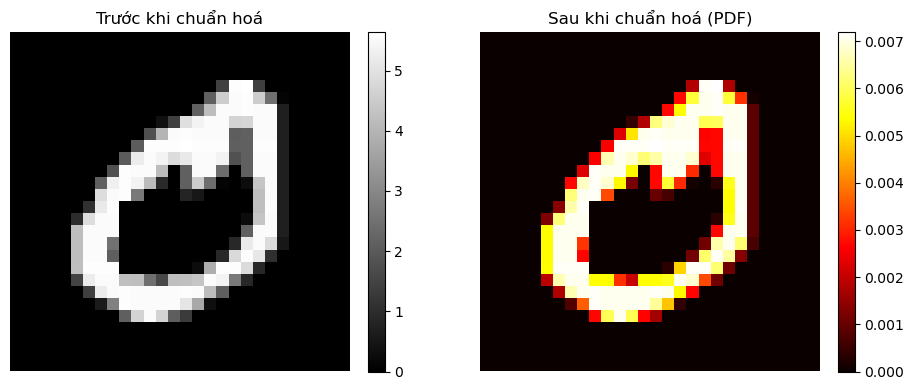

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Ví dụ lấy ảnh đầu tiên
idx = 3
pdf = F_data[idx]

# "Ảnh gốc" (chưa chuẩn hoá): phục hồi bằng tổng pixel
arr_original = pdf * pdf.size  

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(arr_original, cmap="gray")
axs[0].set_title("Trước khi chuẩn hoá")
axs[0].axis("off")
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(pdf, cmap="hot")
axs[1].set_title("Sau khi chuẩn hoá (PDF)")
axs[1].axis("off")
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



In [94]:
bandwidth = 1.0 / 28
nx, ny = 28, 28
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)
grid = np.stack([xx.ravel(), yy.ravel()], axis=1)  # (784, 2)


In [95]:
# ví dụ tạo model
model = IFCF.Model(
    grid_x=grid,
    num_clusters=len(labels_to_take),   # số cụm mong muốn
    fuzziness=2,
    max_iterations=200,
    tolerance=1e-6,
    distance_metric="L2",  # hoặc "L2", "W2"
    bandwidth=bandwidth,
	  init = 'k',
    verbose=True,
    Dim=2
)

# chạy clustering
model.fit(F_data)
U,centroids,_ = model.get_results()

[IFCM] it=001 | dU=3.539e+00 | dTheta=9.924e-02 | ΔJ=inf | J=8.052989e-04 | f=[0.42200174 0.57799826]
[IFCM] it=002 | dU=9.980e-01 | dTheta=9.029e-03 | ΔJ=3.949e-04 | J=4.103987e-04 | f=[0.59955931 0.40044069]
[IFCM] it=003 | dU=3.383e-01 | dTheta=3.864e-03 | ΔJ=3.838e-06 | J=4.065602e-04 | f=[0.63017179 0.36982821]
[IFCM] it=004 | dU=2.238e-01 | dTheta=2.645e-03 | ΔJ=8.987e-07 | J=4.056615e-04 | f=[0.64896854 0.35103146]
Converged by ΔJ.


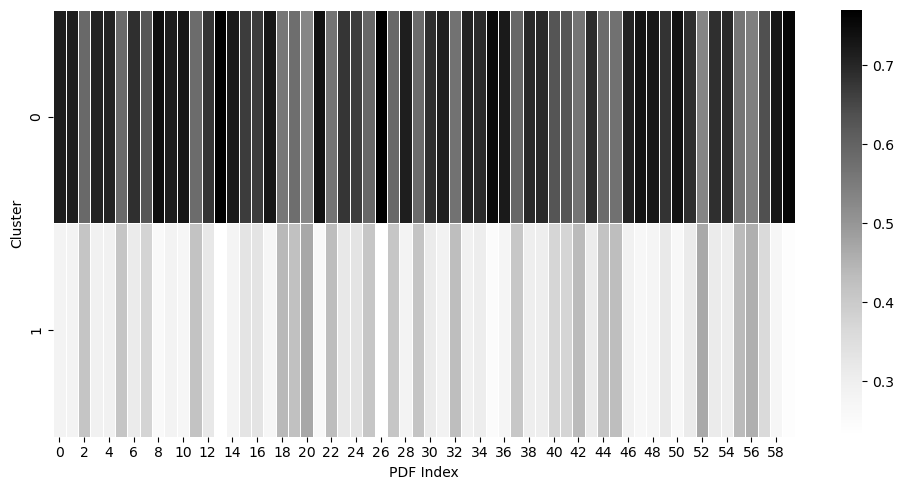

In [96]:
# plotHeatmap_U(U)
plt.figure(figsize=(10, 5))

sns.heatmap(
	U,
	cmap='Greys',
	cbar=True,
	linewidths=0.5,
   
    
)

plt.ylabel('Cluster')
plt.xlabel('PDF Index')
plt.tight_layout()
# plt.savefig('KCF_U.pdf', bbox_inches="tight")

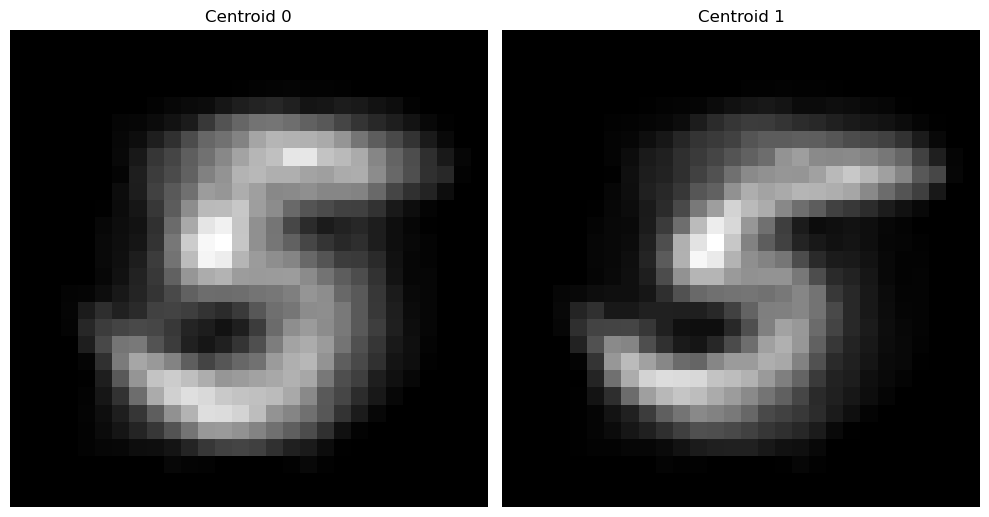

In [97]:
import matplotlib.pyplot as plt

# centroids: (K, 784)  -> reshape thành (28,28)
fig, axes = plt.subplots(1,len(labels_to_take), figsize=(10,20))
axes = axes.ravel()
for i in range(len(centroids)):
	img = centroids[i].reshape(28, 28)
	axes[i].imshow(img, cmap="gray")
	axes[i].set_title(f"Centroid {i}")
	axes[i].axis("off")
plt.tight_layout()
plt.show()



         Cặp       L2  Hellinger  Bhattacharyya  Jensen–Shannon
0(1) vs 0(3) 0.041651   0.335465       0.119388        0.294777
0(1) vs 5(0) 0.081562   0.650082       0.549231        0.550220
0(3) vs 5(0) 0.084997   0.686902       0.638346        0.581872


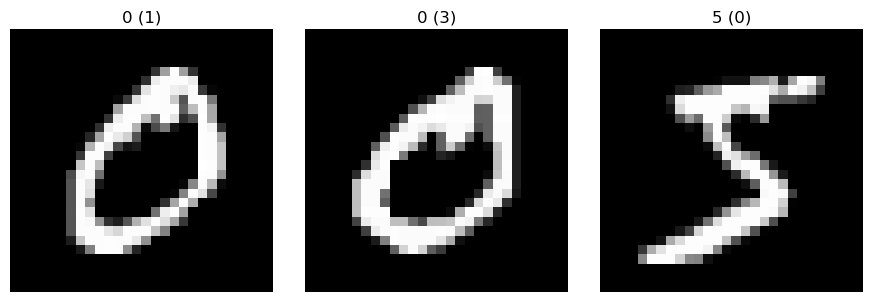

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== Helpers: distances for discrete PDFs ======
def l2_distance(p, q):
    diff = p - q
    return float(np.sqrt(np.sum(diff * diff)))

def hellinger_distance(p, q, eps=1e-12):
    sp = np.sqrt(np.clip(p, eps, None))
    sq = np.sqrt(np.clip(q, eps, None))
    return float((1.0 / np.sqrt(2.0)) * np.linalg.norm(sp - sq))

def bhattacharyya_distance(p, q, eps=1e-12):
    bc = np.sum(np.sqrt(np.clip(p, eps, None) * np.clip(q, eps, None)))
    return float(-np.log(np.clip(bc, eps, 1.0)))

def jensen_shannon_distance(p, q, eps=1e-12):
    p = np.clip(p, eps, None); q = np.clip(q, eps, None)
    m = 0.5*(p+q)
    def kl(a,b): return np.sum(a*np.log(a/b))
    js = 0.5*kl(p,m) + 0.5*kl(q,m)
    return float(np.sqrt(js))

def pdf_pairwise_row(name, A, B):
    return {
        "Cặp": name,
        "L2": l2_distance(A, B),
        "Hellinger": hellinger_distance(A, B),
        "Bhattacharyya": bhattacharyya_distance(A, B),
        "Jensen–Shannon": jensen_shannon_distance(A, B),
    }

# ====== Pick indices: 0(a), 0(b), 5 ======
zero_idxs = np.where(selected_labels == 0)[0]
five_idxs = np.where(selected_labels == 5)[0]
assert len(zero_idxs) >= 2 and len(five_idxs) >= 1, "Cần ≥2 ảnh label=0 và ≥1 ảnh label=5."

# Chọn mặc định: cái đầu và cái thứ hai cho '0', cái đầu cho '5'
i0a, i0b = zero_idxs[0], zero_idxs[1]
i5 = five_idxs[0]

# Bạn có thể tự chỉ định nếu muốn:
# i0a, i0b, i5 = 0, 3, 12   # ví dụ

P0a = F_data[i0a]
P0b = F_data[i0b]
P5  = F_data[i5]

# ====== Compute distances ======
rows = [
    pdf_pairwise_row(f"0({i0a}) vs 0({i0b})", P0a, P0b),
    pdf_pairwise_row(f"0({i0a}) vs 5({i5})",  P0a, P5),
    pdf_pairwise_row(f"0({i0b}) vs 5({i5})",  P0b, P5),
]
df = pd.DataFrame(rows)
print(df.to_string(index=False))

# ====== Quick sanity-check visualization ======
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(P0a, cmap="gray"); axes[0].set_title(f"0 ({i0a})"); axes[0].axis("off")
axes[1].imshow(P0b, cmap="gray"); axes[1].set_title(f"0 ({i0b})"); axes[1].axis("off")
axes[2].imshow(P5,  cmap="gray"); axes[2].set_title(f"5 ({i5})");  axes[2].axis("off")
plt.tight_layout(); plt.show()
